## E-Commerce Sales Data Analysis Using Python

### Step1: Data Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv(r"C:\Users\HP\OneDrive\Desktop\ecommerce_data.csv")

In [3]:
df.head(10)

,Order_ID,Customer_ID,Age,Category,Product_Price,Discount_%,Quantity,Payment_Method,Delivery_Days,Rating,Returned,Platform,Festival_Sale
0,10001,602,40.0,Sports,33640,30.0,1,UPI,7.0,NaN,Yes,Web,No
1,10002,770,18.0,Home,40150,20.0,1,UPI,4.0,4.0,Yes,Web,Yes
2,10003,606,25.0,Electronics,38463,5.0,2,NetBanking,1.0,1.0,Yes,Mobile,No
3,10004,571,18.0,Sports,48475,20.0,3,COD,NaN,4.0,No,Web,No
4,10005,688,18.0,Sports,18942,0.0,3,Card,1.0,4.0,No,Mobile,Yes
5,10006,520,30.0,Beauty,11394,0.0,3,NetBanking,7.0,NaN,No,Web,Yes
6,10007,602,22.0,Beauty,22723,0.0,4,Card,1.0,3.0,No,Mobile,No
7,10008,621,25.0,Beauty,33718,30.0,2,NetBanking,2.0,NaN,No,Mobile,No
8,10009,714,35.0,Electronics,6041,NaN,3,Card,1.0,NaN,No,Mobile,No
9,10010,587,35.0,Electronics,46349,10.0,4,UPI,10.0,5.0,Yes,Mobile,No


In [52]:
df.shape

(1600, 13)

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600 entries, 0 to 1599
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order_ID        1600 non-null   int64  
 1   Customer_ID     1600 non-null   int64  
 2   Age             1403 non-null   float64
 3   Category        1600 non-null   object 
 4   Product_Price   1600 non-null   int64  
 5   Discount_%      1362 non-null   float64
 6   Quantity        1600 non-null   int64  
 7   Payment_Method  1600 non-null   object 
 8   Delivery_Days   1399 non-null   float64
 9   Rating          1360 non-null   float64
 10  Returned        1600 non-null   object 
 11  Platform        1600 non-null   object 
 12  Festival_Sale   1600 non-null   object 
dtypes: float64(4), int64(4), object(5)
memory usage: 162.6+ KB


In [54]:
df.describe()

,Order_ID,Customer_ID,Age,Product_Price,Discount_%,Quantity,Delivery_Days,Rating
count,1600.00000,1600.000000,1403.000000,1600.000000,1362.000000,1600.000000,1399.000000,1360.000000
mean,10800.50000,648.272500,30.717748,25362.446250,13.054332,2.470625,4.438170,3.089706
std,462.02453,86.949531,9.000802,14297.287587,9.885233,1.098814,2.912948,1.412406
min,10001.00000,500.000000,18.000000,316.000000,0.000000,1.000000,1.000000,1.000000
25%,10400.75000,574.000000,22.000000,13305.500000,5.000000,2.000000,2.000000,2.000000
50%,10800.50000,650.000000,30.000000,25432.000000,10.000000,2.000000,4.000000,3.000000
75%,11200.25000,724.000000,40.000000,37844.000000,20.000000,3.000000,7.000000,4.000000
max,11600.00000,799.000000,45.000000,49981.000000,30.000000,4.000000,10.000000,5.000000


In [55]:
df.columns

Index(['Order_ID', 'Customer_ID', 'Age', 'Category', 'Product_Price',
       'Discount_%', 'Quantity', 'Payment_Method', 'Delivery_Days', 'Rating',
       'Returned', 'Platform', 'Festival_Sale'],
      dtype='object')

### Step2: Data Cleaning

#### Duplicate Records Check

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.isnull().sum()

Order_ID            0
Customer_ID         0
Age               197
Category            0
Product_Price       0
Discount_%        238
Quantity            0
Payment_Method      0
Delivery_Days     201
Rating            240
Returned            0
Platform            0
Festival_Sale       0
dtype: int64

In [6]:
df["Age"].mean()
df["Delivery_Days"].median()
df["Rating"].mode()

0    5.0
Name: Rating, dtype: float64

In [7]:
df["Age"].fillna(df["Age"].mean, inplace=True)
df["Discount_%"].fillna(0, inplace=True)
df["Delivery_Days"].fillna(df["Delivery_Days"].median(), inplace=True)
df["Rating"].fillna(df["Rating"].mode()[0], inplace=True)

In [8]:
df

,Order_ID,Customer_ID,Age,Category,Product_Price,Discount_%,Quantity,Payment_Method,Delivery_Days,Rating,Returned,Platform,Festival_Sale
0,10001,602,40.0,Sports,33640,30.0,1,UPI,7.0,5.0,Yes,Web,No
1,10002,770,18.0,Home,40150,20.0,1,UPI,4.0,4.0,Yes,Web,Yes
2,10003,606,25.0,Electronics,38463,5.0,2,NetBanking,1.0,1.0,Yes,Mobile,No
3,10004,571,18.0,Sports,48475,20.0,3,COD,4.0,4.0,No,Web,No
4,10005,688,18.0,Sports,18942,0.0,3,Card,1.0,4.0,No,Mobile,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1595,11596,513,25.0,Sports,21223,15.0,1,Card,3.0,5.0,No,Mobile,Yes
1596,11597,730,30.0,Home,9176,15.0,2,NetBanking,5.0,1.0,No,Web,No
1597,11598,583,22.0,Home,3187,0.0,2,UPI,5.0,1.0,No,Mobile,No
1598,11599,629,18.0,Fashion,42722,20.0,3,COD,2.0,4.0,No,Mobile,No


In [9]:
df.isnull().sum()

Order_ID          0
Customer_ID       0
Age               0
Category          0
Product_Price     0
Discount_%        0
Quantity          0
Payment_Method    0
Delivery_Days     0
Rating            0
Returned          0
Platform          0
Festival_Sale     0
dtype: int64

In [22]:
df

,Order_ID,Customer_ID,Age,Category,Product_Price,Discount_%,Quantity,Payment_Method,Delivery_Days,Rating,Returned,Platform,Festival_Sale
0,10001,602,40.0,Sports,33640,30.0,1,UPI,7.0,5.0,Yes,Web,No
1,10002,770,18.0,Home,40150,20.0,1,UPI,4.0,4.0,Yes,Web,Yes
2,10003,606,25.0,Electronics,38463,5.0,2,NetBanking,1.0,1.0,Yes,Mobile,No
3,10004,571,18.0,Sports,48475,20.0,3,COD,4.0,4.0,No,Web,No
4,10005,688,18.0,Sports,18942,0.0,3,Card,1.0,4.0,No,Mobile,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1595,11596,513,25.0,Sports,21223,15.0,1,Card,3.0,5.0,No,Mobile,Yes
1596,11597,730,30.0,Home,9176,15.0,2,NetBanking,5.0,1.0,No,Web,No
1597,11598,583,22.0,Home,3187,0.0,2,UPI,5.0,1.0,No,Mobile,No
1598,11599,629,18.0,Fashion,42722,20.0,3,COD,2.0,4.0,No,Mobile,No


In [24]:
df.dtypes

Order_ID            int64
Customer_ID         int64
Age                object
Category           object
Product_Price       int64
Discount_%        float64
Quantity            int64
Payment_Method     object
Delivery_Days     float64
Rating            float64
Returned           object
Platform           object
Festival_Sale      object
dtype: object

In [25]:
df['Age'].dtype

dtype('O')

In [29]:
df["Age"] = pd.to_numeric(df["Age"],errors="coerce")

In [32]:
df["Age"] > 0

0       True
1       True
2       True
3       True
4       True
        ... 
1595    True
1596    True
1597    True
1598    True
1599    True
Name: Age, Length: 1600, dtype: bool

In [30]:
df["Rating"] <= 5

0       True
1       True
2       True
3       True
4       True
        ... 
1595    True
1596    True
1597    True
1598    True
1599    True
Name: Rating, Length: 1600, dtype: bool

In [31]:
df

,Order_ID,Customer_ID,Age,Category,Product_Price,Discount_%,Quantity,Payment_Method,Delivery_Days,Rating,Returned,Platform,Festival_Sale
0,10001,602,40.0,Sports,33640,30.0,1,UPI,7.0,5.0,Yes,Web,No
1,10002,770,18.0,Home,40150,20.0,1,UPI,4.0,4.0,Yes,Web,Yes
2,10003,606,25.0,Electronics,38463,5.0,2,NetBanking,1.0,1.0,Yes,Mobile,No
3,10004,571,18.0,Sports,48475,20.0,3,COD,4.0,4.0,No,Web,No
4,10005,688,18.0,Sports,18942,0.0,3,Card,1.0,4.0,No,Mobile,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1595,11596,513,25.0,Sports,21223,15.0,1,Card,3.0,5.0,No,Mobile,Yes
1596,11597,730,30.0,Home,9176,15.0,2,NetBanking,5.0,1.0,No,Web,No
1597,11598,583,22.0,Home,3187,0.0,2,UPI,5.0,1.0,No,Mobile,No
1598,11599,629,18.0,Fashion,42722,20.0,3,COD,2.0,4.0,No,Mobile,No


In [32]:
df["Returned"] = df["Returned"].str.strip().str.capitalize()
df["Festival_Sale"] = df["Festival_Sale"].str.strip().str.capitalize()

In [33]:
df

,Order_ID,Customer_ID,Age,Category,Product_Price,Discount_%,Quantity,Payment_Method,Delivery_Days,Rating,Returned,Platform,Festival_Sale
0,10001,602,40.0,Sports,33640,30.0,1,UPI,7.0,5.0,Yes,Web,No
1,10002,770,18.0,Home,40150,20.0,1,UPI,4.0,4.0,Yes,Web,Yes
2,10003,606,25.0,Electronics,38463,5.0,2,NetBanking,1.0,1.0,Yes,Mobile,No
3,10004,571,18.0,Sports,48475,20.0,3,COD,4.0,4.0,No,Web,No
4,10005,688,18.0,Sports,18942,0.0,3,Card,1.0,4.0,No,Mobile,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1595,11596,513,25.0,Sports,21223,15.0,1,Card,3.0,5.0,No,Mobile,Yes
1596,11597,730,30.0,Home,9176,15.0,2,NetBanking,5.0,1.0,No,Web,No
1597,11598,583,22.0,Home,3187,0.0,2,UPI,5.0,1.0,No,Mobile,No
1598,11599,629,18.0,Fashion,42722,20.0,3,COD,2.0,4.0,No,Mobile,No


In [33]:
df.head(5)

,Order_ID,Customer_ID,Age,Category,Product_Price,Discount_%,Quantity,Payment_Method,Delivery_Days,Rating,Returned,Platform,Festival_Sale
0,10001,602,43097.0,Sports,33640,30.0,1,UPI,7.0,5.0,Yes,Web,No
1,10002,770,43097.0,Home,40150,20.0,1,UPI,4.0,4.0,Yes,Web,Yes
2,10003,606,43097.0,Electronics,38463,5.0,2,NetBanking,1.0,1.0,Yes,Mobile,No
3,10004,571,43097.0,Sports,48475,20.0,3,COD,4.0,4.0,No,Web,No
4,10005,688,43097.0,Sports,18942,0.0,3,Card,1.0,4.0,No,Mobile,Yes


In [34]:
df.dtypes

Order_ID            int64
Customer_ID         int64
Age               float64
Category           object
Product_Price       int64
Discount_%        float64
Quantity            int64
Payment_Method     object
Delivery_Days     float64
Rating            float64
Returned           object
Platform           object
Festival_Sale      object
dtype: object

In [36]:
df["Discount_%"].dtypes

dtype('float64')

In [37]:
df["Product_Price"] = df["Product_Price"].astype(int)

In [38]:
df["Quantity"] = df["Quantity"].astype(int)

In [39]:
df.dtypes

Order_ID            int64
Customer_ID         int64
Age               float64
Category           object
Product_Price       int64
Discount_%        float64
Quantity            int64
Payment_Method     object
Delivery_Days     float64
Rating            float64
Returned           object
Platform           object
Festival_Sale      object
dtype: object

In [35]:
df["Total_Amount"] = df["Product_Price"]*df["Quantity"]*(1 - df["Discount_%"]/100)

In [36]:
df

,Order_ID,Customer_ID,Age,Category,Product_Price,Discount_%,Quantity,Payment_Method,Delivery_Days,Rating,Returned,Platform,Festival_Sale,Total_Amount
0,10001,602,43097.0,Sports,33640,30.0,1,UPI,7.0,5.0,Yes,Web,No,23548.00
1,10002,770,43097.0,Home,40150,20.0,1,UPI,4.0,4.0,Yes,Web,Yes,32120.00
2,10003,606,43097.0,Electronics,38463,5.0,2,NetBanking,1.0,1.0,Yes,Mobile,No,73079.70
3,10004,571,43097.0,Sports,48475,20.0,3,COD,4.0,4.0,No,Web,No,116340.00
4,10005,688,43097.0,Sports,18942,0.0,3,Card,1.0,4.0,No,Mobile,Yes,56826.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1595,11596,513,43097.0,Sports,21223,15.0,1,Card,3.0,5.0,No,Mobile,Yes,18039.55
1596,11597,730,43097.0,Home,9176,15.0,2,NetBanking,5.0,1.0,No,Web,No,15599.20
1597,11598,583,43097.0,Home,3187,0.0,2,UPI,5.0,1.0,No,Mobile,No,6374.00
1598,11599,629,43097.0,Fashion,42722,20.0,3,COD,2.0,4.0,No,Mobile,No,102532.80


In [42]:
df.head()

,Order_ID,Customer_ID,Age,Category,Product_Price,Discount_%,Quantity,Payment_Method,Delivery_Days,Rating,Returned,Platform,Festival_Sale,Total_Amount
0,10001,602,40.0,Sports,33640,30.0,1,UPI,7.0,5.0,Yes,Web,No,23548.0
1,10002,770,18.0,Home,40150,20.0,1,UPI,4.0,4.0,Yes,Web,Yes,32120.0
2,10003,606,25.0,Electronics,38463,5.0,2,NetBanking,1.0,1.0,Yes,Mobile,No,73079.7
3,10004,571,18.0,Sports,48475,20.0,3,COD,4.0,4.0,No,Web,No,116340.0
4,10005,688,18.0,Sports,18942,0.0,3,Card,1.0,4.0,No,Mobile,Yes,56826.0


In [43]:
df["Category"].value_counts()

Category
Home           343
Electronics    335
Sports         333
Beauty         306
Fashion        283
Name: count, dtype: int64

In [44]:
df["Payment_Method"].value_counts()

Payment_Method
Card          421
NetBanking    400
UPI           395
COD           384
Name: count, dtype: int64

### Step3: Exploratory Data Analytics

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

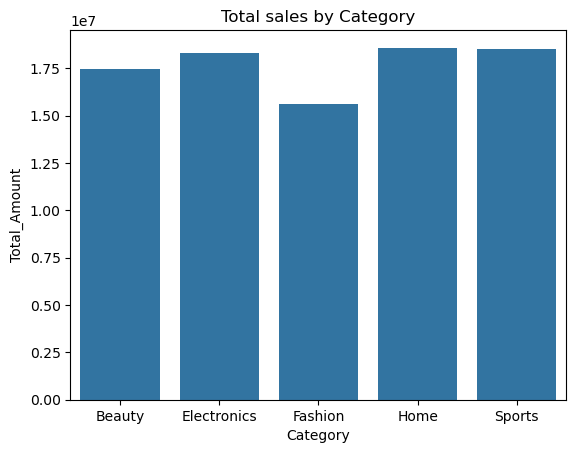

In [46]:
category_sales = df.groupby("Category")["Total_Amount"].sum().reset_index()
plt.figure()
sns.barplot(x="Category", y="Total_Amount", data=category_sales)
plt.title("Total sales by Category")
plt.show()

Insight: Electronic gengerated highest revenue
         Fashion shows high volume but lower revenue

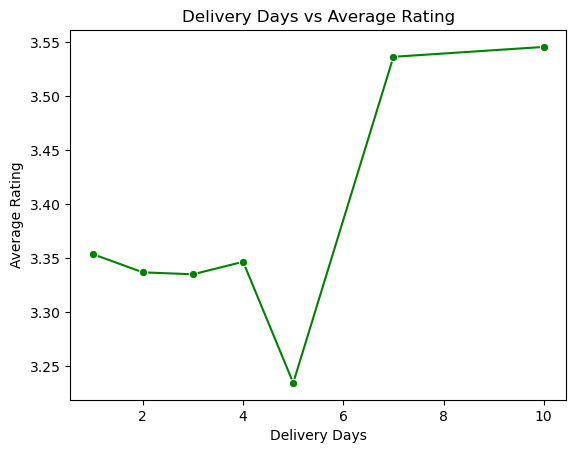

In [47]:
delivery_rating = df.groupby("Delivery_Days")["Rating"].mean().reset_index()
plt.figure()
sns.lineplot(
    x="Delivery_Days", y="Rating", data=delivery_rating, color= "green" , marker="o")
plt.title("Delivery Days vs Average Rating")
plt.xlabel("Delivery Days")
plt.ylabel("Average Rating")
plt.show()

Insight: Faster Delivery leads to higher customer rating.

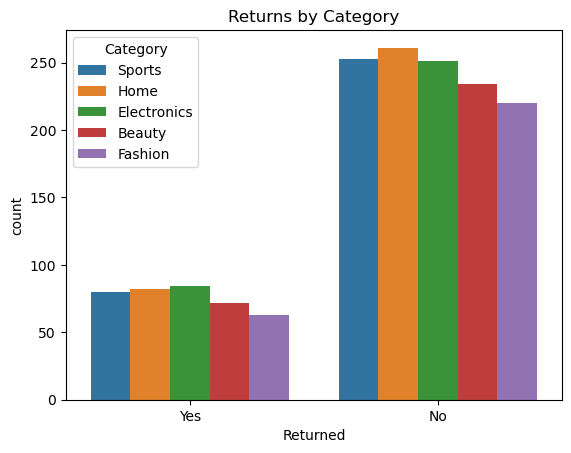

In [48]:
plt.figure()
sns.countplot(x="Returned", hue="Category", data=df)
plt.title("Returns by Category")
plt.show()


Insight: Electronics Category has higher return rate

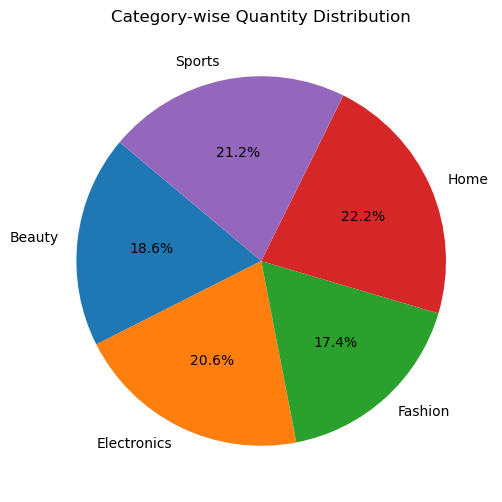

In [50]:
cat_qty = df.groupby("Category", as_index=False).agg({"Quantity":"sum"})
plt.figure(figsize=(6,6))
plt.pie(cat_qty["Quantity"], labels=cat_qty["Category"], autopct="%1.1f%%", startangle=140)
plt.title("Category-wise Quantity Distribution")
plt.show()

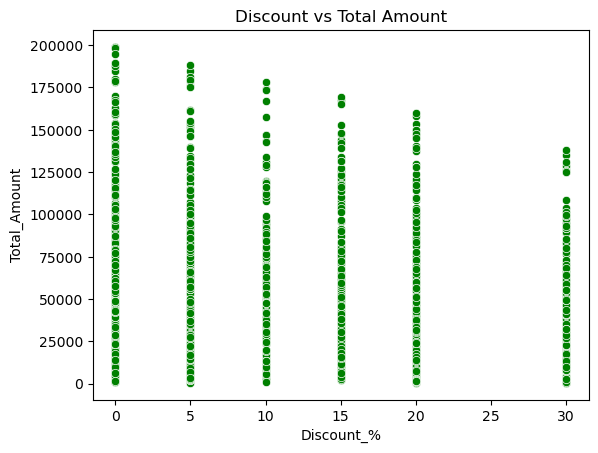

In [67]:
plt.figure()
sns.scatterplot(x="Discount_%", y="Total_Amount",
                data=df, color="Green")
plt.title("Discount vs Total Amount")
plt.show()

Insight: The Plot shows that medium discounts (10-20%) generate better revenue, while very high discount reduce 
the total order value. Hence, discounts have a non-linear impact on sales.

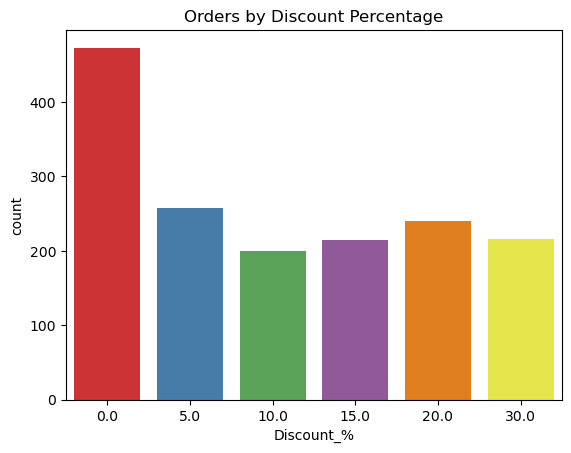

In [42]:
plt.figure()
sns.countplot(x="Discount_%", data=df, palette="Set1")
plt.title("Orders by Discount Percentage")
plt.show()

Insight: Orders are highest at 10-20% discounts, showing moderate discounts are most effective.

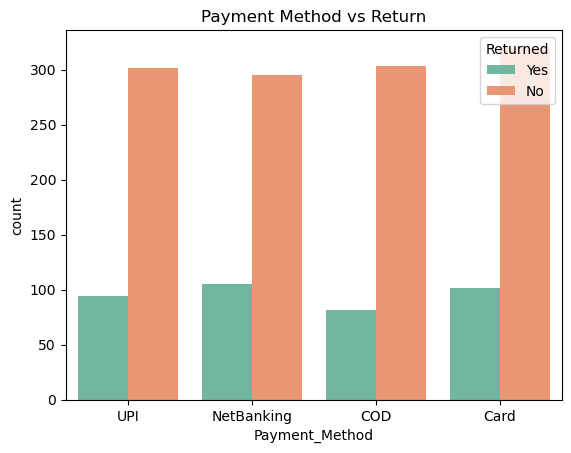

In [58]:
plt.figure()
sns.countplot(x="Payment_Method", hue="Returned", data=df, palette="Set2")
plt.title("Payment Method vs Return")
plt.show()

Insight: COD payment method shows a higher return rate compared to prepaid methods like UPI and Card.

Conclusion: This Project analyzes e-commerce data to identify sales trends, customer behaviour, and operational efficieny using python.
the insights help businesses improve profitability and customer satisfaction through data-driven decisions.